# C5/C6 Light Naphtha Isomerization

A light straight-run naphtha is mostly pentanes and hexanes, and its normal paraffins
have poor octanes: n-pentane is about 62 RON and n-hexane about 25. An isomerization
unit rearranges them over a platinum catalyst into their branched isomers, and saturates
the benzene on the way. Isopentane is about 92 RON and 2,2-dimethylbutane about 92
(the values the module uses, marked verify there).

This notebook runs `difflow_refinery.isomerization` (#311):

1. the isomer equilibrium, which sets the ceiling;
2. the once-through unit on two feeds, and the inlet temperature that maximises RON;
3. exact gradients, checked against finite differences;
4. the deisohexanizer (DIH) recycle;
5. the unit as a planning block feeding a gasoline pool.

**What is assumed.** The rate constants are illustrative, not fitted to any catalyst.
The feeds' speciation is constructed, not measured. The pure-component octanes were
recalled, not checked against the printed tables. The numbers show how the model
behaves; none of them is a prediction for a real unit. See
`docs/unit-operations-refinery.md` for what is and is not validated.

In [1]:
import time
import warnings

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from difflow.planning import Network
from difflow_refinery.blending import BlendComponent, BlendPool
from difflow_refinery.isomerization import (
    OUTPUT_NAMES, IsomerizationHydrogenWarning, IsomerizationUnit, IsomerizationUnitParams,
    constructed_feed, equilibrium_table, isom_block, link_isom)
from difflow_refinery.isomerization import thermochem as tc

C = 273.15
def y(vec, name):
    return float(vec[OUTPUT_NAMES.index(name)])

## 1. The equilibrium

Every equilibrium constant follows from the species' ideal-gas heats of formation,
entropies and Cp. `equilibrium_table(T)` gives each isomer family's equilibrium
distribution in closed form. The branched isomers are favoured cold. That is the whole
argument for the low-temperature catalysts.

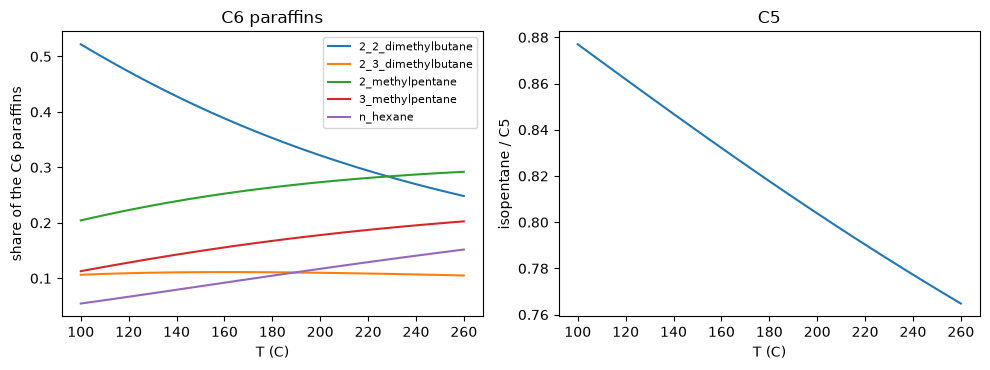

In [2]:
T = np.linspace(100, 260, 33) + C
tab = [equilibrium_table(t) for t in T]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
for n in tc.NAMES:
    if n in tab[0]["C6P"]:
        ax[0].plot(T - C, [float(d["C6P"][n]) for d in tab], label=n)
ax[0].set(xlabel="T (C)", ylabel="share of the C6 paraffins", title="C6 paraffins")
ax[0].legend(fontsize=8)
ax[1].plot(T - C, [float(d["C5"]["isopentane"]) for d in tab])
ax[1].set(xlabel="T (C)", ylabel="isopentane / C5", title="C5")
plt.tight_layout()

## 2. Once through, on two feeds

`constructed_feed` builds a light naphtha from an **assumed** composition. The
paraffinic feed has about 1.5 wt % benzene in its C6 cut. The benzene-rich one, from a
naphthenic crude, has about 5 wt % and more naphthenes. Benzene saturation is strongly
exothermic, so the second feed heats the bed much more.

The unit charges the feed with hydrogen at `H2_HC = 0.3`, runs the adiabatic bed, flashes
the effluent and stabilises the liquid to a 90 kPa RVP.

In [3]:
FEEDS = {k: constructed_feed(k, 10.0) for k in ("paraffinic", "benzene_rich")}
once = IsomerizationUnit(IsomerizationUnitParams())     # 140 C, LHSV 2, 30 bar
rows = {}
for k, f in FEEDS.items():
    t0 = time.time()
    iso, gas, info = once(f)
    o = info["outputs"]
    rows[k] = o
    print(f"{k:13s} RON {float(o['RON']):6.2f}  MON {float(o['MON']):6.2f}  "
          f"vol yield {float(o['yield_volume']):.4f}  bed dT {float(o['reactor_dT']):5.1f} K  "
          f"benzene conv {float(o['benzene_conversion']):.4f}  ({time.time() - t0:.0f} s)")
    b = once.balances(f, {"streams": info["streams"], "info": info})
    print("   balances:", {n: f"{float(v):.1e}" for n, v in b.items()})

paraffinic    RON  82.18  MON  80.08  vol yield 0.9880  bed dT  31.6 K  benzene conv 1.0000  (14 s)
   balances: {'mass': '-1.8e-16', 'C2': '-8.3e-17', 'C3': '3.3e-16', 'C4': '0.0e+00', 'C5': '-1.2e-16', 'C6': '2.4e-16', 'C7': '0.0e+00'}


benzene_rich  RON  81.56  MON  78.58  vol yield 1.0075  bed dT  69.9 K  benzene conv 1.0000  (4 s)
   balances: {'mass': '1.8e-16', 'C2': '0.0e+00', 'C3': '-2.7e-15', 'C4': '0.0e+00', 'C5': '-1.6e-16', 'C6': '-4.3e-16', 'C7': '0.0e+00'}


The volume yield of the benzene-rich feed exceeds one. Saturating benzene adds
hydrogen and makes a less dense liquid.

### RON against inlet temperature

Cold, the bed is far from equilibrium. Hot, it reaches equilibrium but the equilibrium
itself is worse. So RON has a maximum in the inlet temperature. `once.outputs` is the
unit's output vector as a function of `T_in` and `LHSV`.

The benzene-rich feed is swept only up to 150 C. Above about 160 C its exotherm drives
hydrocracking, which uses up the hydrogen, and `IsomerizationHydrogenWarning` fires.

15 solves in 69 s
paraffinic    best of the sweep: RON 82.47 at 150 C
benzene_rich  best of the sweep: RON 82.16 at 120 C


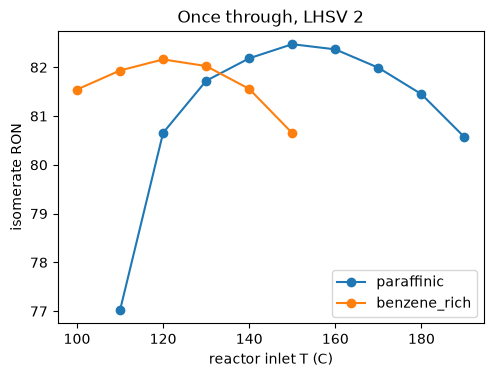

In [4]:
sweep = {"paraffinic": np.arange(110, 195, 10.0), "benzene_rich": np.arange(100, 155, 10.0)}
ron = {}
t0 = time.time()
for k, Ts in sweep.items():
    ron[k] = [y(once.outputs(FEEDS[k], t + C, 2.0), "RON") for t in Ts]
print(f"{sum(map(len, sweep.values()))} solves in {time.time() - t0:.0f} s")
for k in sweep:
    i = int(np.argmax(ron[k]))
    print(f"{k:13s} best of the sweep: RON {ron[k][i]:.2f} at {sweep[k][i]:.0f} C")
fig, ax = plt.subplots(figsize=(5.5, 3.8))
for k in sweep:
    ax.plot(sweep[k], ron[k], "o-", label=k)
ax.set(xlabel="reactor inlet T (C)", ylabel="isomerate RON", title="Once through, LHSV 2")
ax.legend();

## 3. Exact gradients

The reactor is integrated by an implicit Runge-Kutta method whose stages are solved by
Newton in a `lax.while_loop`. That loop has no reverse-mode rule, so the unit is
differentiated in **forward mode** (`jax.jacfwd`). Here the derivatives of RON and the
volume yield with respect to `T_in` and `LHSV` are checked against central differences.

In [5]:
f = FEEDS["paraffinic"]
u0 = jnp.asarray([413.15, 2.0])
fn = lambda u: once.outputs(f, u[0], u[1])
J = jax.jacfwd(fn)(u0)
steps = [2e-4, 3e-5]
for j, (lever, h) in enumerate(zip(("T_in", "LHSV"), steps)):
    e = jnp.zeros(2).at[j].set(h)
    fd = (fn(u0 + e) - fn(u0 - e)) / (2 * h)
    for name in ("RON", "yield_volume"):
        i = OUTPUT_NAMES.index(name)
        print(f"d{name}/d{lever}: AD {float(J[i, j]): .8e}  FD {float(fd[i]): .8e}  "
              f"rel {abs(float(J[i, j] - fd[i])) / abs(float(fd[i])):.1e}")

dRON/dT_in: AD  4.23581553e-02  FD  4.23581553e-02  rel 3.1e-10
dyield_volume/dT_in: AD -1.83775725e-04  FD -1.83775726e-04  rel 6.6e-09


dRON/dLHSV: AD -5.70946570e-01  FD -5.70946569e-01  rel 4.4e-10
dyield_volume/dLHSV: AD  2.07530028e-03  FD  2.07530029e-03  rel 5.8e-09


## 4. The deisohexanizer recycle

A DIH takes the dimethylbutanes overhead and the naphthenes out of the bottom, both as
isomerate. Its side draw, the methylpentanes and n-hexane, goes back to the reactor for
another pass. The recycle is a `difflow.Flowsheet` recycle converged by Anderson
acceleration. This is the slow cell: one to three minutes.

In [6]:
dih = IsomerizationUnit(IsomerizationUnitParams(configuration="dih", dih_side_draw=6.0))
t0 = time.time()
iso, gas, info = dih(FEEDS["paraffinic"])
o = info["outputs"]
print(f"converged {info['loop']['converged']} in {info['loop']['iterations']} iterations, "
      f"closure {info['loop']['closure']:.1e} mol/s ({time.time() - t0:.0f} s)")
print(f"RON {float(o['RON']):.2f} against {float(rows['paraffinic']['RON']):.2f} once through")
print(f"2,2-DMB / C6P at the reactor outlet: {float(o['22DMB_C6P']):.3f}")
print(f"DIH reboiler duty {float(o['dih_duty']) / 1e6:.2f} MW, "
      f"recycle {float(o['recycle_mass']):.3f} kg/s")

converged True in 8 iterations, closure 1.0e-10 mol/s (79 s)
RON 82.81 against 82.18 once through
2,2-DMB / C6P at the reactor outlet: 0.205
DIH reboiler duty 6.92 MW, recycle 6.000 kg/s


The gain is modest here: about 0.6 RON. These rate constants and the constructed feed
are not fitted to any unit, so the size of the gain is not a finding.

`dih.outputs(...)` differentiates the converged loop by the implicit function theorem,
`dy/du = Y_u + Y_x (I - G_x)^-1 G_u`, through a `jax.custom_jvp`. The release tests
check those gradients against finite differences to 1e-5. They are not run here,
because each costs several more loop solves.

## 5. The isomerate in a gasoline pool

`isom_block` turns the unit into a `difflow.planning.Block`. Its delta vectors are the
forward-mode Jacobian of the unit. `link_isom` connects the isomerate volume to a
`BlendPool` block whose component is named `"isomerate"`. The reformate here is a
made-up component, there to make a pool.

In [7]:
blk = isom_block(once, f, levers=("T_in", "LHSV"),
                 outputs=("isomerate_V", "RON", "yield_volume"))
iso_c = once.blend_component(rows["paraffinic"])
reformate = BlendComponent.from_properties(
    "reformate", SG=0.82, RON=98.0, MON=88.0, RVP_psi=4.0, olefins_vol=0.0,
    aromatics_vol=60.0, benzene_vol=1.0)
pool = BlendPool("gasoline").as_block(
    [iso_c, reformate], u0=[float(rows["paraffinic"]["isomerate_volume"]), 50.0])
net = Network([blk, pool], link_isom(blk, pool))
print("links:", link_isom(blk, pool))
t0 = time.time()
D = jax.jacfwd(blk.fn)(jnp.asarray(blk.u0))
print(f"delta vectors ({time.time() - t0:.0f} s), per C and per 1/h:")
for name, row in zip(blk.y_names, D):
    print(f"  {name:13s} {float(row[0]): .4e}  {float(row[1]): .4e}")

links: [('isom.isomerate_V', 'gasoline.isomerate_V')]


delta vectors (8 s), per C and per 1/h:
  isomerate_V   -1.0071e-02   1.1373e-01
  RON            4.2358e-02  -5.7095e-01
  yield_volume  -1.8378e-04   2.0753e-03


The isomerate's octane in the pool is the one at the linearisation point: a
`BlendComponent` has fixed properties. Rebuild it from `blend_component` at each new
base point.